# 08 - Analyses croisées

## Objectif

Cette analyse croise plusieurs variables du dataset afin d'identifier des relations et des tendances entre les contenus.

Nous allons notamment étudier les relations entre :

- le type de contenu et l'année de sortie ;
- le type de contenu et la classification ;
- les catégories et le type de contenu ;
- les pays et le type de contenu ;
- l'année de sortie et la classification.


## 1. Importation des bibliothèques

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 2. Chargement des données

In [ ]:
df = pd.read_csv("../data/processed/netflix_titles_clean.csv")

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

print(f"Nombre de contenus : {len(df)}")


Nombre de contenus : 8807


## 3. Type de contenu × année de sortie

In [ ]:
type_year = (
    df.groupby(["release_year", "type"])
    .size()
    .unstack(fill_value=0)
)

type_year.tail(20)


type,Movie,TV Show
release_year,,
2002,44,7
2003,51,10
2004,55,9
2005,67,13
2006,82,14
2007,74,14
2008,113,23
2009,118,34
2010,154,40


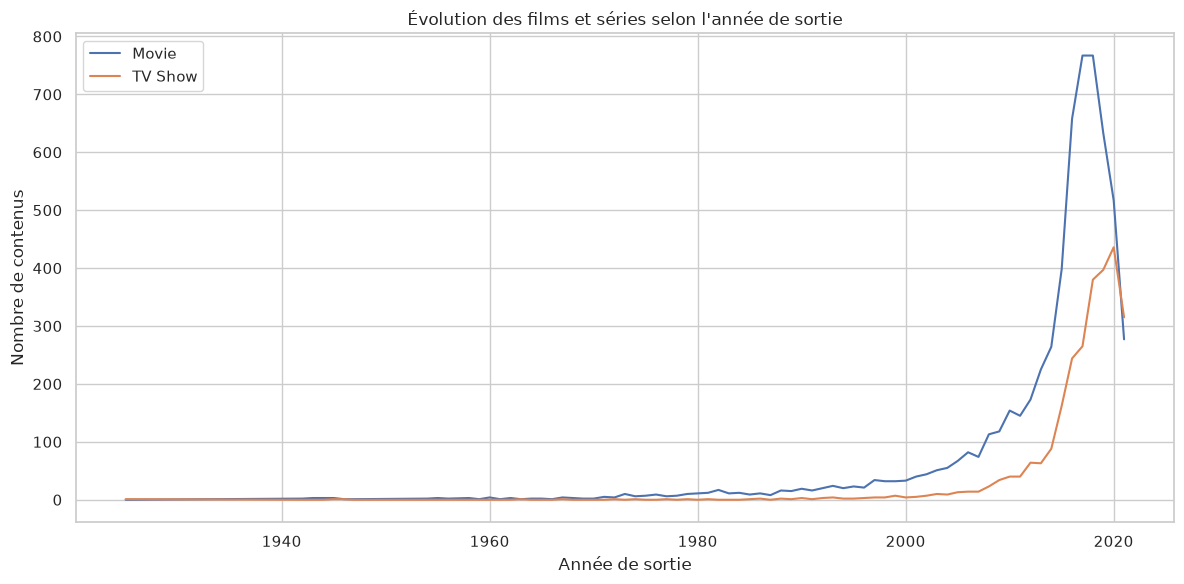

In [ ]:
plt.figure(figsize=(12, 6))

for content_type in type_year.columns:
    plt.plot(
        type_year.index,
        type_year[content_type],
        label=content_type
    )

plt.title("Évolution des films et séries selon l'année de sortie")
plt.xlabel("Année de sortie")
plt.ylabel("Nombre de contenus")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Type de contenu × classification

In [ ]:
rating_type = pd.crosstab(
    df["rating"],
    df["type"]
)

rating_type


type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


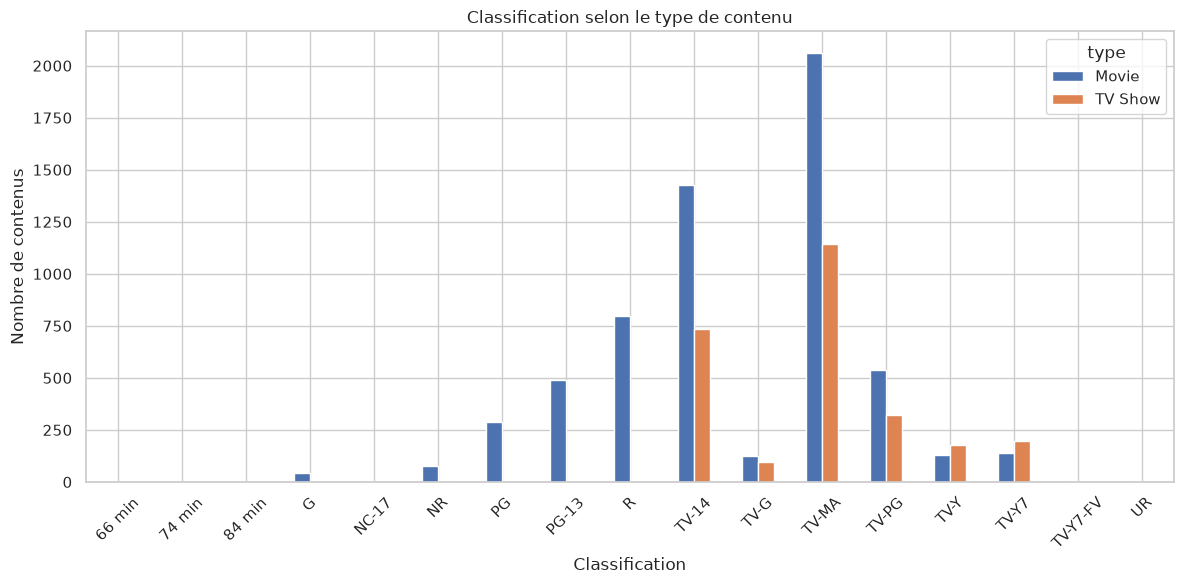

In [ ]:
rating_type.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification selon le type de contenu")
plt.xlabel("Classification")
plt.ylabel("Nombre de contenus")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Catégories × type de contenu

In [ ]:
df_categories = df.assign(
    category=df["listed_in"].str.split(", ")
).explode("category")

category_type = (
    df_categories
    .groupby(["category", "type"])
    .size()
    .unstack(fill_value=0)
)

category_type["Total"] = category_type.sum(axis=1)

category_type.sort_values(
    "Total",
    ascending=False
).head(15)


type,Movie,TV Show,Total
category,,,
International Movies,2752,0,2752
Dramas,2427,0,2427
Comedies,1674,0,1674
International TV Shows,0,1351,1351
Documentaries,869,0,869
Action & Adventure,859,0,859
TV Dramas,0,763,763
Independent Movies,756,0,756
Children & Family Movies,641,0,641


## 6. Pays × type de contenu

In [ ]:
df_countries = df.assign(
    country=df["country"].str.split(", ")
).explode("country")

country_type = (
    df_countries
    .groupby(["country", "type"])
    .size()
    .unstack(fill_value=0)
)

country_type["Total"] = country_type.sum(axis=1)

country_type.sort_values(
    "Total",
    ascending=False
).head(15)


type,Movie,TV Show,Total
country,,,
United States,2751,938,3689
India,962,84,1046
Unknown,440,391,831
United Kingdom,532,272,804
Canada,319,126,445
France,303,90,393
Japan,119,199,318
Spain,171,61,232
South Korea,61,170,231


## 7. Année × classification

In [ ]:
recent_df = df[
    df["release_year"] >= 2010
].copy()

year_rating = pd.crosstab(
    recent_df["release_year"],
    recent_df["rating"]
)

year_rating.tail(15)


rating,66 min,74 min,84 min,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
release_year,,,,,,,,,,,,,,,,,
2010,0,0,1,0,0,4,8,26,26,50,3,42,20,6,8,0,0
2011,0,0,0,1,0,2,18,23,20,55,2,27,18,8,11,0,0
2012,0,0,0,0,0,5,7,19,29,73,3,54,23,8,15,1,0
2013,0,0,0,0,1,9,14,15,41,75,13,64,29,5,20,1,0
2014,0,0,0,2,1,7,15,19,49,99,7,79,47,14,12,1,0
2015,1,0,0,0,0,18,11,25,67,144,11,184,63,20,14,0,0
2016,0,0,0,3,0,20,14,34,86,218,22,341,97,31,33,2,1
2017,0,1,0,1,0,2,15,32,73,251,26,451,111,31,37,0,0
2018,0,0,0,2,1,1,31,30,52,268,26,549,105,41,40,1,0


## 8. Évolution des principales classifications

In [ ]:
top_ratings = (
    df["rating"]
    .value_counts()
    .head(5)
    .index
)

rating_evolution = (
    df[df["rating"].isin(top_ratings)]
    .groupby(["release_year", "rating"])
    .size()
    .unstack(fill_value=0)
)

rating_evolution.tail(20)


rating,PG-13,R,TV-14,TV-MA,TV-PG
release_year,,,,,
2002,14,12,11,7,2
2003,10,16,16,8,3
2004,7,7,15,10,10
2005,16,10,26,8,10
2006,15,12,31,17,10
2007,15,14,18,17,6
2008,24,19,38,25,9
2009,25,25,48,18,16
2010,26,26,50,42,20


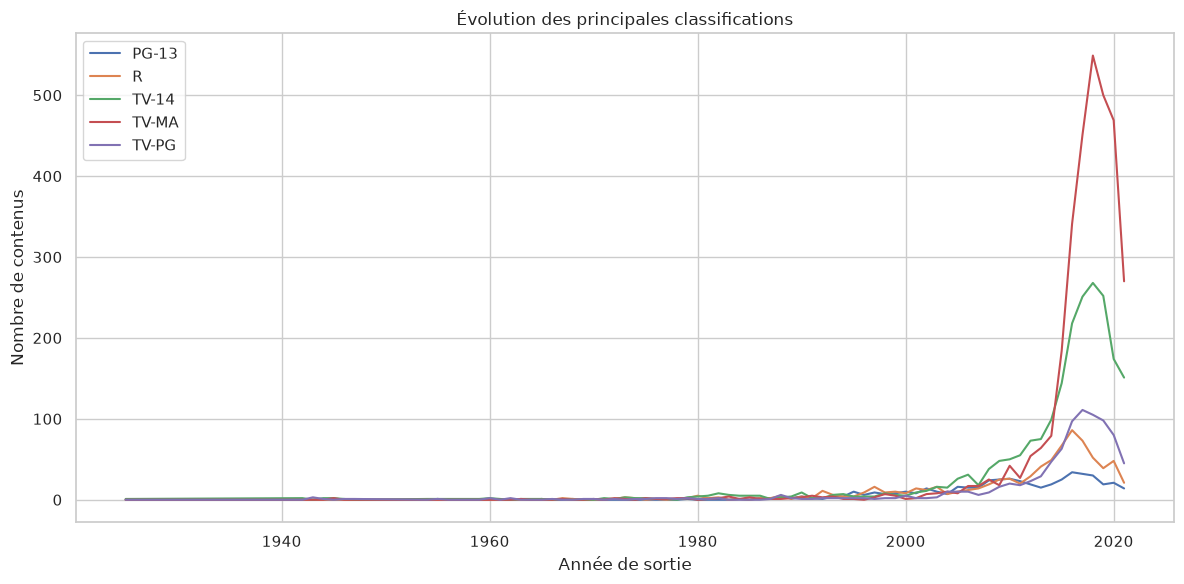

In [ ]:
plt.figure(figsize=(12, 6))

for rating in rating_evolution.columns:
    plt.plot(
        rating_evolution.index,
        rating_evolution[rating],
        label=rating
    )

plt.title("Évolution des principales classifications")
plt.xlabel("Année de sortie")
plt.ylabel("Nombre de contenus")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Nombre de catégories selon le type

In [ ]:
df["category_count"] = (
    df["listed_in"]
    .str.split(", ")
    .str.len()
)

category_count_by_type = (
    df.groupby("type")["category_count"]
    .agg(["mean", "median", "max"])
    .round(2)
)

category_count_by_type


,mean,median,max
type,,,
Movie,2.15,2.0,3
TV Show,2.29,2.0,3


## 10. Nombre de pays associés selon le type

In [ ]:
df["country_count"] = (
    df["country"]
    .str.split(", ")
    .str.len()
)

country_count_by_type = (
    df.groupby("type")["country_count"]
    .agg(["mean", "median", "max"])
    .round(2)
)

country_count_by_type


,mean,median,max
type,,,
Movie,1.27,1.0,12
TV Show,1.13,1.0,8


## 11. Contenus récents × type

In [ ]:
recent_content = df[
    df["release_year"] >= 2015
]

recent_distribution = (
    recent_content["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

recent_distribution


type
Movie      64.62
TV Show    35.38
Name: proportion, dtype: float64

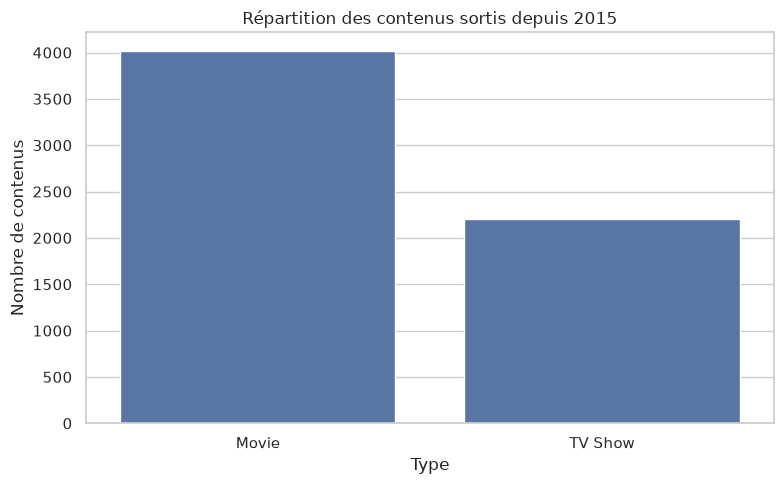

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=recent_content,
    x="type"
)

plt.title("Répartition des contenus sortis depuis 2015")
plt.xlabel("Type")
plt.ylabel("Nombre de contenus")
plt.tight_layout()
plt.show()


## 12. Principaux résultats

In [ ]:
print("=== TYPE ===")
print(df["type"].value_counts())

print("\n=== PRINCIPALES CLASSIFICATIONS ===")
print(df["rating"].value_counts().head(5))

print("\n=== ANNÉES LES PLUS REPRÉSENTÉES ===")
print(df["release_year"].value_counts().head(5))

print("\n=== CATÉGORIES PRINCIPALES ===")
print(df_categories["category"].value_counts().head(5))

print("\n=== PAYS PRINCIPAUX ===")
print(df_countries["country"].value_counts().head(5))


=== TYPE ===
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

=== PRINCIPALES CLASSIFICATIONS ===
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

=== ANNÉES LES PLUS REPRÉSENTÉES ===
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64

=== CATÉGORIES PRINCIPALES ===
category
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

=== PAYS PRINCIPAUX ===
country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
Name: count, dtype: int64


## 13. Conclusion

Les analyses croisées permettent d'aller au-delà des distributions individuelles.

Elles mettent en relation plusieurs caractéristiques du catalogue et permettent d'identifier des tendances selon le type de contenu, la période, les classifications, les catégories et les pays.

Ces résultats serviront de base à la synthèse finale du projet.
